# Yellow Taxi Trip Records EDA
1. Introduction
2. Dataset overview
3. Initial profiling
4. Validation against the TLC Data Dictionary
5. Exploratory Data Analysis
    1. Missing values and special block
    2. Monetary values
    3. Dates and duration
    4. Distance and speed
    5. Duplicates
    6. Passenger and categorical values
6. Final findings
7. Cleaning recommendations

## 1. Introduction

**Dataset**: Yellow Taxi Trip Records. January 2024

**Source URL**: https://d37ci6vzurychx.cloudfront.net/trip-data

**Dictionary URL**: https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf

This notebook contains exploratory data analysis of NYC Yellow Taxi Trip Dataset, on the 


## 2. Dataset overview

### 2.1 Setup and data loading

In [170]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [171]:
FILE_PATH = Path("data/raw_download/yellow_tripdata_2024-01.parquet")

pd.set_option("display.max_columns", None)      # show all columns
pd.set_option("display.width", 200)             # show more characters in a row
pd.set_option("display.max_rows", 100)          # show more rows

print(FILE_PATH)
print("File exists:", FILE_PATH.exists())

file_size_bytes = FILE_PATH.stat().st_size
file_size_mb = file_size_bytes / 1024**2

print(f"Size: {file_size_mb:.2f} MB")

data/raw_download/yellow_tripdata_2024-01.parquet
File exists: True
Size: 47.65 MB


In [172]:
df = pd.read_parquet(FILE_PATH)

### 2.2 Dataset structure

In [167]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())
df.head()

2964624 rows, 19 columns
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [168]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

### First observations
- `VendorID` - right type, category
- `pickup`, `dropoff` - right type, date recognized
- `passenger_count` - wrong type, **possible NaN values**
- `trip_distance` - right type
- `RatecodeID` - wrong type, **possible NaN values**
- `store_and_fwd_flag` - category
- `PULocationID` - right type, location coordinates
- `DOLocationID` - right type, location, coordinates
- `payment_type` - right type, category
- `fare_amount`, `extra`, `tip_amount`, `tolls_amount`, `total_amount` - right type, money


In [145]:
categorical_columns = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type",
]

for col in categorical_columns:
    print("=" * 66 + f"\n")
    print(df[col].value_counts(dropna=False).sort_index())
    print(f"\n")


VendorID
1     729732
2    2234632
6        260
Name: count, dtype: int64



RatecodeID
1.0     2663350
2.0       98713
3.0        7954
4.0        6365
5.0       19410
6.0           7
99.0      28663
NaN      140162
Name: count, dtype: int64



store_and_fwd_flag
N      2813126
Y        11336
NaN     140162
Name: count, dtype: int64



payment_type
0     140162
1    2319046
2     439191
3      19597
4      46628
Name: count, dtype: int64




`VendorID` - contains unexpected value: 6

`payment_type` - is 0 right value?

`payment_type`, `store_and_fwd_flag`, `payment_type` - same amount of NaN values (140162)

This suggests these records may originate from a different ingestion process or have incomplete metadata.

## 3. Initial profiling

### 3.1 Missing data

In [146]:
mask = (
    df["RatecodeID"].isna() & df["store_and_fwd_flag"].isna() & (df["payment_type"] == 0)
)
print(mask.sum())

df.loc[mask].head()

140162


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
2824462,2,2024-01-01 00:34:19,2024-01-01 00:51:22,NaN,2.04,NaN,NaN,143,141,0,12.72,0.0,0.5,0.00,0.0,1.0,16.72,NaN,NaN
2824463,1,2024-01-01 00:14:31,2024-01-01 00:19:29,NaN,1.60,NaN,NaN,236,238,0,9.30,1.0,0.5,2.86,0.0,1.0,17.16,NaN,NaN
2824464,1,2024-01-01 00:35:11,2024-01-01 01:13:40,NaN,0.00,NaN,NaN,142,79,0,21.01,0.0,0.5,0.00,0.0,1.0,25.01,NaN,NaN
2824465,1,2024-01-01 00:33:37,2024-01-01 00:50:34,NaN,0.00,NaN,NaN,237,4,0,17.79,0.0,0.5,0.00,0.0,1.0,21.79,NaN,NaN
2824466,1,2024-01-01 00:49:04,2024-01-01 01:01:16,NaN,0.00,NaN,NaN,244,50,0,34.65,0.0,0.5,0.00,0.0,1.0,38.65,NaN,NaN


In [147]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID               140162
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee              140162
dtype: int64

### Observations

#### VendorID
- Contains three unique values: 1, 2 and 6.
- VendorID = 6 occurs only 260 times and should be verified.

#### Missing values pattern
Exactly 140162 records contain missing values in:
- passenger_count
- RatecodeID
- store_and_fwd_flag
- congestion_surcharge
- Airport_fee

The same records also contain:

- payment_type = 0
This indicates a consistent missing-data pattern rather than random missing values.

#### Trip data

Some trips have:
- trip_distance = 0
- positive fare_amount
- positive total_amount

These records should be investigated before deciding whether they are invalid.

In [148]:
normal_trips = df.loc[~mask]
special_trips = df.loc[mask]

In [149]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=False)
})

summary

,dtype,missing,missing_%,unique
VendorID,int32,0,0.00,3
tpep_pickup_datetime,datetime64[us],0,0.00,1575706
tpep_dropoff_datetime,datetime64[us],0,0.00,1574780
passenger_count,float64,140162,4.73,11
trip_distance,float64,0,0.00,4489
RatecodeID,float64,140162,4.73,8
store_and_fwd_flag,str,140162,4.73,3
PULocationID,int32,0,0.00,260
DOLocationID,int32,0,0.00,261
payment_type,int64,0,0.00,5


In [150]:
numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
VendorID,2964624.0,1.754204,0.432590,1.00,2.00,2.00,2.00,6.00
passenger_count,2824462.0,1.339281,0.850282,0.00,1.00,1.00,1.00,9.00
trip_distance,2964624.0,3.652169,225.462572,0.00,1.00,1.68,3.11,312722.30
RatecodeID,2824462.0,2.069359,9.823219,1.00,1.00,1.00,1.00,99.00
PULocationID,2964624.0,166.017884,63.623914,1.00,132.00,162.00,234.00,265.00
DOLocationID,2964624.0,165.116712,69.315350,1.00,114.00,162.00,234.00,265.00
payment_type,2964624.0,1.161271,0.580869,0.00,1.00,1.00,1.00,4.00
fare_amount,2964624.0,18.175062,18.949548,-899.00,8.60,12.80,20.50,5000.00
extra,2964624.0,1.451598,1.804102,-7.50,0.00,1.00,2.50,14.25
mta_tax,2964624.0,0.483382,0.117760,-0.50,0.50,0.50,0.50,4.00


#### Observations

Suspicious values

| Column | Susp. min | Susp. max |
| --- | --- | --- |
| `trip_distance` | ― | 312722.3 |
| `fare_amount` | -899 | 5000 |
| `total_amount` | -900 | 5000 |
| `tip_amount` | -80 | ― |
| `tolls_amount` | -80 | ― |
| `improvement_surcharge` | -1 | ― |
| `Airport_fee` | -1.75 | ― |
| `VendorID` | ― | 6 |
| `RatecodeID` | ― | 99 |

In [161]:
for col in numeric_columns:
    print("=" * 77)
    print(f"{col}, MIN: {df[col].min()}, MAX: {df[col].max()}")

VendorID, MIN: 1, MAX: 6
passenger_count, MIN: 0.0, MAX: 9.0
trip_distance, MIN: 0.0, MAX: 312722.3
RatecodeID, MIN: 1.0, MAX: 99.0
PULocationID, MIN: 1, MAX: 265
DOLocationID, MIN: 1, MAX: 265
payment_type, MIN: 0, MAX: 4
fare_amount, MIN: -899.0, MAX: 5000.0
extra, MIN: -7.5, MAX: 14.25
mta_tax, MIN: -0.5, MAX: 4.0
tip_amount, MIN: -80.0, MAX: 428.0
tolls_amount, MIN: -80.0, MAX: 115.92
improvement_surcharge, MIN: -1.0, MAX: 1.0
total_amount, MIN: -900.0, MAX: 5000.0
congestion_surcharge, MIN: -2.5, MAX: 2.5
Airport_fee, MIN: -1.75, MAX: 1.75


In [163]:
print("Trip distance = 0:", (df["trip_distance"] == 0).sum())
print("Trip distance > 100 miles:", (df["trip_distance"] > 100).sum())
print("Trip distance > 500 miles:", (df["trip_distance"] > 500).sum())

print("Fare amount = 0:", (df["fare_amount"] == 0).sum())
print("Fare amount < 0:", (df["fare_amount"] < 0).sum())
print("Fare amount > 500:", (df["fare_amount"] > 500).sum())

print("Total amount = 0:", (df["total_amount"] == 0).sum())
print("Total amount < 0:", (df["total_amount"] < 0).sum())
print("Total amount > 500:", (df["total_amount"] > 500).sum())

print("Tip amount = 0:", (df["tip_amount"] == 0).sum())
print("Tip amount < 0:", (df["tip_amount"] < 0).sum())
print("Tip amount > 100:", (df["tip_amount"] > 100).sum())

print("Tolls amount = 0:", (df["tolls_amount"] == 0).sum())
print("Tolls amount < 0:", (df["tolls_amount"] < 0).sum())
print("Tolls amount > 100:", (df["tolls_amount"] > 100).sum())

print("Extra amount = 0:", (df["extra"] == 0).sum())
print("Extra amount < 0:", (df["extra"] < 0).sum())
print("Extra amount > 100:", (df["extra"] > 100).sum())

print("improvement_surcharge = 0:", (df["improvement_surcharge"] == 0).sum())
print("improvement_surcharge < 0:", (df["improvement_surcharge"] < 0).sum())

# print("Airport_fee = 0:", (df["Airport_fee"] == 0).sum())
# print("Airport_fee < 0:", (df["Airport_fee"] < 0).sum())

print("passenger_count = 0:", (df["passenger_count"] == 0).sum())

print("VendorID = 6:", (df["VendorID"] == 6).sum())

Trip distance = 0: 60371
Trip distance > 100 miles: 59
Trip distance > 500 miles: 25
Fare amount = 0: 893
Fare amount < 0: 37448
Fare amount > 500: 46
Total amount = 0: 416
Total amount < 0: 35504
Total amount > 500: 62
Tip amount = 0: 710292
Tip amount < 0: 102
Tip amount > 100: 26
Tolls amount = 0: 2753809
Tolls amount < 0: 2035
Tolls amount > 100: 2
Extra amount = 0: 1290548
Extra amount < 0: 17548
Extra amount > 100: 0
improvement_surcharge = 0: 838
improvement_surcharge < 0: 35502
passenger_count = 0: 31465
VendorID = 6: 260


### Initial outlier analysis

#### Distance

- 60371 trips have `trip_distance` = 0.
- 59 trips have a distance greater than 100 miles.
- 25 trips have a distance greater than 500 miles.
- Extreme distances are rare, but zero-distance trips require further analysis using trip duration and fare information.

#### Negative monetary values

Negative values occur in multiple monetary columns.

The number of records with:

- `total_amount` < 0: 35504
- `improvement_surcharge` < 0: 35502

is nearly identical.

This suggests that negative values may represent complete transaction reversals, cancellations or corrections rather than isolated data-entry errors.

#### Zero values

Zero values are not automatically invalid:

- zero tips may represent trips without recorded tips,
- zero tolls are expected for trips without toll roads,
- zero airport fees are expected for non-airport trips.

#### Rate codes

`RatecodeID` = 99 occurs 28663 times and requires verification.

Values greater than 2 should not be treated as anomalous as a group because some higher rate codes may be valid.

### Anomaly summary in %

In [18]:
def anomaly_result(name, condition):
    count = int(condition.sum())
    percentage = count / len(df) * 100
    
    return {"condition": name, "count": count, "percentage": round(percentage, 4)}

anomaly_summary = pd.DataFrame([anomaly_result("Trip distance = 0", df["trip_distance"] == 0),
                                anomaly_result("Trip distance > 100 miles", df["trip_distance"] > 100),
                                anomaly_result("Trip distance > 500 miles", df["trip_distance"] > 500),
                                anomaly_result("Fare amount = 0", df["fare_amount"] == 0),
                                anomaly_result("Fare amount < 0", df["fare_amount"] < 0),
                                anomaly_result("Fare amount > 500", df["fare_amount"] > 500),
                                anomaly_result("Total amount = 0", df["total_amount"] == 0),
                                anomaly_result("Total amount < 0", df["total_amount"] < 0),
                                anomaly_result("Total amount > 500", df["total_amount"] > 500),
                                anomaly_result("Passenger count = 0", df["passenger_count"] == 0),
                                anomaly_result("RatecodeID > 2", df["RatecodeID"]>2)])

anomaly_summary.sort_values(by="percentage", ascending=False)

,condition,count,percentage
10,RatecodeID > 2,62399,2.1048
0,Trip distance = 0,60371,2.0364
4,Fare amount < 0,37448,1.2632
7,Total amount < 0,35504,1.1976
9,Passenger count = 0,31465,1.0613
3,Fare amount = 0,893,0.0301
6,Total amount = 0,416,0.0140
8,Total amount > 500,62,0.0021
1,Trip distance > 100 miles,59,0.0020
5,Fare amount > 500,46,0.0016


### Plots
#### Distance plots

99.5 percentile: 21.63


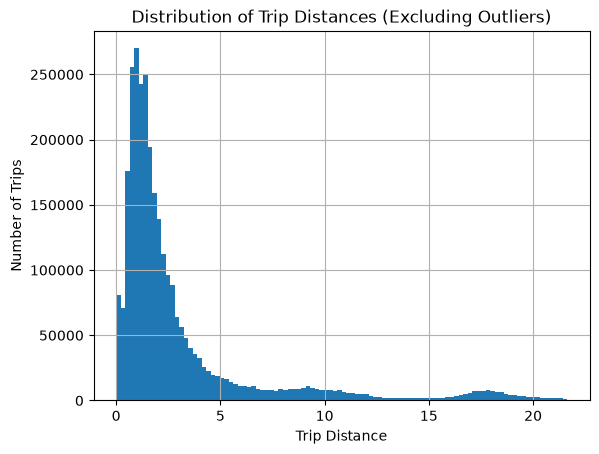

In [19]:
distance_limit = df["trip_distance"].quantile(0.995)

print("99.5 percentile:", distance_limit)

df.loc[df["trip_distance"].between(0, distance_limit), "trip_distance"].hist(bins=100)
plt.xlabel("Trip Distance")
plt.ylabel("Number of Trips")
plt.title("Distribution of Trip Distances (Excluding Outliers)")
plt.show()

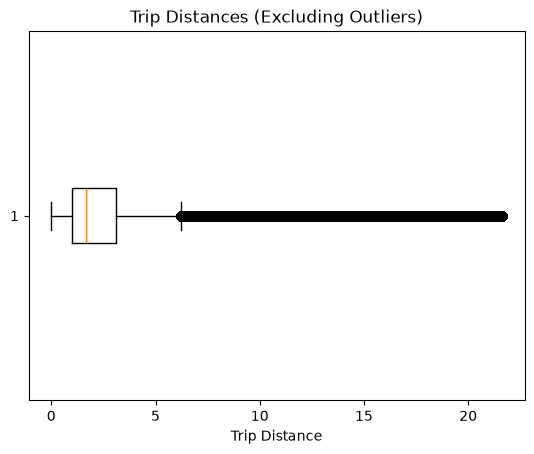

In [20]:
distance_for_plot = df.loc[df["trip_distance"] <= distance_limit, "trip_distance"]

plt.boxplot(distance_for_plot, orientation="horizontal")
plt.xlabel("Trip Distance")
plt.title("Trip Distances (Excluding Outliers)")
plt.show()

#### Total amount plots

Total amount 0.5 percentile: -17.8
Total amount 99.5 percentile: 113.56884999999775


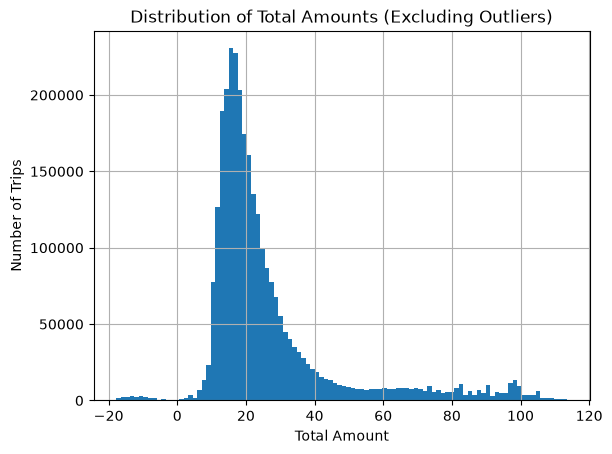

In [21]:
lower_limit = df["total_amount"].quantile(0.005)
upper_limit = df["total_amount"].quantile(0.995)

print("Total amount 0.5 percentile:", lower_limit)
print("Total amount 99.5 percentile:", upper_limit)

total_amount_for_plot = df.loc[df["total_amount"].between(lower_limit, upper_limit), "total_amount"]

total_amount_for_plot.hist(bins=100)
plt.xlabel("Total Amount")
plt.ylabel("Number of Trips")
plt.title("Distribution of Total Amounts (Excluding Outliers)")
plt.show()

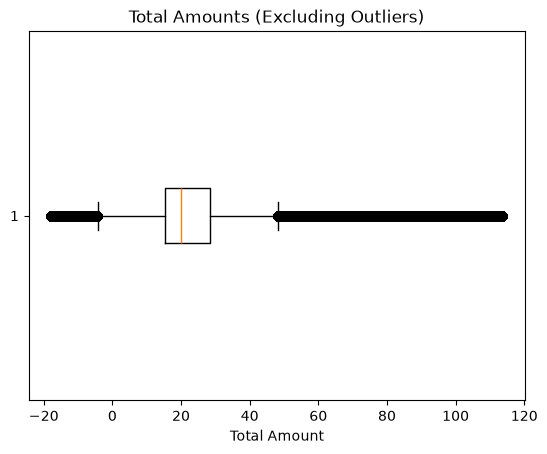

In [22]:
plt.boxplot(total_amount_for_plot, orientation="horizontal")

plt.title("Total Amounts (Excluding Outliers)")
plt.xlabel("Total Amount")
plt.show()

### Negative Patterns


In [23]:


negative_pattern = pd.DataFrame({
    "fare_amount_negative": df["fare_amount"] < 0,
    "total_amount_negative": df["total_amount"] < 0,
    "extra_negative": df["extra"] < 0,
    "mta_tax_negative": df["mta_tax"] < 0,
    "tip_amount_negative": df["tip_amount"] < 0,
    "tolls_amount_negative": df["tolls_amount"] < 0,
    "improvement_surcharge_negative": df["improvement_surcharge"] < 0,
    "congestion_surcharge_negative": df["congestion_surcharge"] < 0,
    "Airport_fee_negative": df["Airport_fee"] < 0,
})

negative_pattern.sum().sort_values(ascending=False)
negative_columns_per_rows = negative_pattern.sum(axis=1)
negative_columns_per_rows.value_counts().sort_index()

negative_total_trips = df.loc[df["total_amount"] < 0, 
                              ["fare_amount", "total_amount", "extra", "mta_tax", "tip_amount", 
                               "tolls_amount", "improvement_surcharge", "congestion_surcharge", 
                               "Airport_fee"]]

negative_total_trips.head(20)

,fare_amount,total_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee
99,-13.5,-18.50,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
506,-31.5,-34.25,0.0,0.0,0.0,0.0,-1.0,0.0,-1.75
536,-5.8,-10.80,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
552,-33.1,-38.10,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
682,-47.8,-52.80,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
999,-9.3,-14.30,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
1057,-11.4,-16.40,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
1195,-40.1,-45.10,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
1382,-3.0,-8.00,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00
1472,-11.4,-16.40,-1.0,-0.5,0.0,0.0,-1.0,-2.5,0.00


### Wnioski

### 1. Potwierdzenie dokładnego wzorca braków

Sprawdzamy:

* czy wszystkie sześć warunków dotyczy dokładnie tych samych rekordów,
* czy istnieją rekordy spełniające tylko część warunków,
* czy grupa jest jednym ciągłym blokiem na końcu pliku.

Jeśli grupa jest jednym ciągłym blokiem

Będzie to mocny dowód, że jest to osobna partia lub inny sposób dostarczenia danych.

Jeśli rekordy są rozproszone

Wzorzec może wynikać z określonego typu transakcji, urządzenia albo warunków biznesowych, a nie z osobnego batcha.

In [24]:
special_pattern_checks = pd.DataFrame({
    "passenger_count missing": df["passenger_count"].isna(),
    "RatecodeID missing": df["RatecodeID"].isna(),
    "store_and_fwd_flag missing": df["store_and_fwd_flag"].isna(),
    "congestion_surcharge missing": df["congestion_surcharge"].isna(),
    "Airport_fee missing": df["Airport_fee"].isna(),
    "payment_type zero": df["payment_type"] == 0,
})

special_mask = special_pattern_checks.all(axis=1)
print("amount of records matching one condition:")
print(special_pattern_checks.sum())
print("\namount of records matching all conditions:")
print(special_mask.sum())

partial_special_mask = (special_pattern_checks.any(axis=1) & ~special_mask)
print("\namount of records matching partial conditions:")
print(partial_special_mask.sum())

amount of records matching one condition:
passenger_count missing         140162
RatecodeID missing              140162
store_and_fwd_flag missing      140162
congestion_surcharge missing    140162
Airport_fee missing             140162
payment_type zero               140162
dtype: int64

amount of records matching all conditions:
140162

amount of records matching partial conditions:
0


In [25]:
special_pattern_checks = pd.DataFrame({
    "passenger_count missing": df["passenger_count"].isna(),
    "RatecodeID missing": df["RatecodeID"].isna(),
    "store_and_fwd_flag missing": df["store_and_fwd_flag"].isna(),
    "congestion_surcharge missing": df["congestion_surcharge"].isna(),
    "Airport_fee missing": df["Airport_fee"].isna(),
    "payment_type zero": df["payment_type"] == 0,
    
})

special_mask = special_pattern_checks.all(axis=1)
print("amount of records matching one condition:")
print(special_pattern_checks.sum())
print("\namount of records matching all conditions:")
print(special_mask.sum())

partial_special_mask = (special_pattern_checks.any(axis=1) & ~special_mask)
print("\namount of records matching partial conditions:")
print(partial_special_mask.sum())

amount of records matching one condition:
passenger_count missing         140162
RatecodeID missing              140162
store_and_fwd_flag missing      140162
congestion_surcharge missing    140162
Airport_fee missing             140162
payment_type zero               140162
dtype: int64

amount of records matching all conditions:
140162

amount of records matching partial conditions:
0


### 2. Czy rekordy są jednym ciągłym blokiem?

Dopiero tabela odpowie, czy ujemne wartości mają związek z brakami.

Jeśli ujemne rekordy występują prawie wyłącznie poza grupą specjalną

Mamy dwa oddzielne problemy:

* specjalny batch z brakami metadanych,
* ujemne transakcje o charakterze korektowym.

Jeśli duża część ujemnych rekordów należy do grupy specjalnej

Musimy analizować je jako część tego samego procesu źródłowego.

In [26]:
special_positions = np.flatnonzero(special_mask.to_numpy())

print("Positions of special records:")
print("first special position:", special_positions[0])
print("last special position:", special_positions[-1])

is_contiguous = np.all(np.diff(special_positions) == 1)
print("Are special records contiguous?", is_contiguous)

Positions of special records:
first special position: 2824462
last special position: 2964623
Are special records contiguous? True


### 3. grupa danych a znak total_amount

In [27]:
record_group = pd.Series(np.where(special_mask, "special_missing_group", "standard_group"), index=df.index, name="record_group")

total_sign = pd.Series(
    np.select(
        [
            df["total_amount"] < 0, 
            df["total_amount"] == 0
        ], 
        [
            "negative", 
            "zero"
        ], 
        default="positive"
    ), 
    index=df.index, 
    name="total_sign"
)

group_sign_counts = pd.crosstab(record_group, total_sign, margins=True)

group_sign_counts


total_sign,negative,positive,zero,All
record_group,,,,
special_missing_group,2,140149,11,140162
standard_group,35502,2788555,405,2824462
All,35504,2928704,416,2964624


In [28]:
group_sign_percentages = (pd.crosstab(record_group, total_sign, normalize="index").mul(100)).round(4)

group_sign_percentages

total_sign,negative,positive,zero
record_group,,,
special_missing_group,0.0014,99.9907,0.0078
standard_group,1.2569,98.7287,0.0143


### 4. Dokładne uzgodnienie kwot dla standardowych rekordów

**Jeśli zgodność wynosi niemal 100%:**

Ujemne transakcje są spójne finansowo. Nie są przypadkowym zbiorem uszkodzonych komórek.

**Jeśli zgodność jest znacznie niższa**

Wtedy wyświetlimy tylko rekordy z największymi różnicami i zbadamy je osobno.

In [29]:

amount_components = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee"
]

complete_component_sum = df[amount_components].sum(axis=1, min_count=len(amount_components))

exact_total_difference = (df["total_amount"] - complete_component_sum).round(2)

    

def summarize_exact_reconciliation(name, mask ):
    differences = exact_total_difference.loc[mask].dropna()
    
    return {
        "group" : name,
        "rows" : int(mask.sum()),
        "comparable_rows" : len(differences),
        "matching_within_1_cent" : int((differences.abs().le(0.01)).sum()),
        "matching_percentage" : round(differences.abs().le(0.01).mean() * 100, 4, ),
        "median_absolute_difference" : differences.abs().median(),
        "maximum_absolute_difference" : differences.abs().max()
                                       
    }
    
standard_reconciliation = pd.DataFrame(
    [
        summarize_exact_reconciliation("standard / negative total", (~special_mask) & (df["total_amount"] < 0)),
        summarize_exact_reconciliation("standard / zero total", (~special_mask) & (df["total_amount"] == 0)),
        summarize_exact_reconciliation("standard / positive total", (~special_mask) & (df["total_amount"] > 0))
    ]
)

standard_reconciliation

,group,rows,comparable_rows,matching_within_1_cent,matching_percentage,median_absolute_difference,maximum_absolute_difference
0,standard / negative total,35502,35502,35399,99.7099,0.0,2.50
1,standard / zero total,405,405,402,99.2593,0.0,2.50
2,standard / positive total,2788555,2788555,2152746,77.1993,0.0,4.25


### 5. Reszta finansowa grupy specjalnej

In [30]:
known_component_sum = df[amount_components].sum(axis=1, skipna=True)

special_residual = (df["total_amount"] - known_component_sum).round(2)

special_residual_counts = (special_residual.loc[special_mask].value_counts().rename("count").to_frame()) 
special_residual_counts["percent age"] = ( special_residual_counts["count"] / special_mask.sum() * 100).round(4)

special_residual_counts

,count,percent age
2.50,125088,89.2453
0.00,14239,10.1590
4.50,792,0.5651
2.00,42,0.0300
1.75,1,0.0007


## Financial and missing-data analysis — conclusions

### Structurally incomplete records

Exactly 140,162 records share the same missing-data pattern:

- missing `passenger_count`
- missing `RatecodeID`
- missing `store_and_fwd_flag`
- missing `congestion_surcharge`
- missing `Airport_fee`
- `payment_type = 0`

These records form one contiguous block at the end of the dataset.
They represent a structurally different batch rather than randomly
missing values.

They will be retained and marked with an `is_special_record` flag.

Missing surcharge values will not be replaced with zero. In 89.25% of
these records, the difference between `total_amount` and the sum of
available components is exactly 2.50, suggesting that a charge included
in the total is absent from the detailed columns.

### Negative transactions

Negative transactions occur almost exclusively in the standard part of
the dataset and are independent of the structurally incomplete batch.

For standard records with negative `total_amount`, 99.71% reconcile with
their monetary components within one cent.

Negative values therefore appear to form internally consistent signed
transactions rather than random field corruption.

They will be retained and marked with an
`is_negative_transaction` flag.

### Total reconciliation

Some positive records do not exactly reconcile with the available
monetary components. The discrepancy is generally small.

An `amount_residual` value and an `is_total_mismatch` flag will be
retained for quality monitoring, but this issue will not block further
processing.

In [31]:
df["is_special_record"] = special_mask

df["is_negative_transaction"] = (
    df["total_amount"] < 0
)

df["amount_residual"] = (
    df["total_amount"] - known_component_sum
).round(2)

df["is_total_mismatch"] = (
    df["amount_residual"].abs() > 0.01
)

## Stage 2 - trip distance, speed, duration, 

Teraz przechodzimy do problemu, który rzeczywiście wymaga analizy outlierów:

- trip_distance = 312 722 mil
- trip_distance = 0
- czas przejazdu
- średnia prędkość
- daty spoza stycznia

To pozwoli nam rozstrzygnąć, które kursy są fizycznie niemożliwe.

In [32]:
### 1. Utwórz czas przejazdu

In [33]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"]
    - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

duration_quantiles = df["trip_duration_minutes"].quantile(
    [0, 0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999, 1]
)

duration_quantiles

0.000     -13.566667
0.001       0.066667
0.010       0.600000
0.250       7.150000
0.500      11.633333
0.750      18.683333
0.990      60.450000
0.999     114.871033
1.000    9455.400000
Name: trip_duration_minutes, dtype: float64

### 2. Sprawdź nielogiczne i ekstremalne czasy

In [34]:
duration_checks = pd.Series({
    "duration < 0": (
        df["trip_duration_minutes"] < 0
    ).sum(),

    "duration = 0": (
        df["trip_duration_minutes"] == 0
    ).sum(),

    "duration < 1 minute": (
        df["trip_duration_minutes"].between(
            0,
            1,
            inclusive="neither",
        )
    ).sum(),

    "duration > 6 hours": (
        df["trip_duration_minutes"] > 360
    ).sum(),

    "duration > 24 hours": (
        df["trip_duration_minutes"] > 1440
    ).sum(),
})

duration_checks




duration < 0              56
duration = 0             814
duration < 1 minute    34251
duration > 6 hours      1772
duration > 24 hours       16
dtype: int64

### 3. Sprawdź zakres dat 

In [35]:
date_range = pd.Series({
    "earliest pickup": df["tpep_pickup_datetime"].min(),
    "latest pickup": df["tpep_pickup_datetime"].max(),
    "earliest dropoff": df["tpep_dropoff_datetime"].min(),
    "latest dropoff": df["tpep_dropoff_datetime"].max(),
})

date_range

earliest pickup    2002-12-31 22:59:39
latest pickup      2024-02-01 00:01:15
earliest dropoff   2002-12-31 23:05:41
latest dropoff     2024-02-02 13:56:52
dtype: datetime64[us]

### I policz kursy, których odbiór nie przypada na styczeń 2024:

In [36]:
outside_january = ~df["tpep_pickup_datetime"].between(
    "2024-01-01 00:00:00",
    "2024-01-31 23:59:59.999999",
)

print(
    "Pickups outside January 2024:",
    outside_january.sum(),
)


Pickups outside January 2024: 18


### 4. Oblicz średnią prędkość tylko dla logicznych czasów

In [73]:
valid_duration_mask = (df["trip_duration_minutes"] > 0)

df["average_speed_mph"] = pd.NA

df.loc[ valid_duration_mask, "average_speed_mph", ] = ( 
        df.loc[valid_duration_mask, "trip_distance"] / (
        df.loc[valid_duration_mask, "trip_duration_minutes", ] / 60
    )
)

df["average_speed_mph"] = pd.to_numeric(df["average_speed_mph"])

df["average_speed_mph"] = df["average_speed_mph"].round(2)

speed_quantiles = df["average_speed_mph"].quantile([0, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1])
# speed_quantiles = df["average_speed_mph"].quantile([0, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1]).round(2)

speed_quantiles

0.000          0.00
0.250          7.24
0.500          9.57
0.750         13.03
0.950         26.11
0.990         37.01
0.999         49.02
1.000    1443333.69
Name: average_speed_mph, dtype: float64

In [74]:
speed_checks = pd.Series({
    "speed = 0": (
        df["average_speed_mph"] == 0
    ).sum(),

    "speed > 80 mph": (
        df["average_speed_mph"] > 80
    ).sum(),
 
    "speed > 100 mph": (
        df["average_speed_mph"] > 100
    ).sum(),

    "speed > 200 mph": (
        df["average_speed_mph"] > 200
    ).sum(),
})

speed_checks

speed = 0          59621
speed > 80 mph      1107
speed > 100 mph     1024
speed > 200 mph      830
dtype: int64

In [81]:
# 1.1

high_speed_mask = df["average_speed_mph"] > 80

high_speed_causes = pd.Series({"all high-speed records": high_speed_mask.sum(),
                                "duration < 1 minute": (high_speed_mask & (df["trip_duration_minutes"] < 1)).sum(),
                                "trip_distance > 100 miles": (high_speed_mask & (df["trip_distance"] > 100)).sum(),
                                "trip_distance > 500 miles": (high_speed_mask & (df["trip_distance"] > 500)).sum(),
                                "outside January": (high_speed_mask & outside_january).sum(),
                                "special missing group": (high_speed_mask & special_mask).sum(),
                                "negative transaction": (high_speed_mask & df["is_negative_transaction"]).sum()
                            })
high_speed_causes

all high-speed records       1107
duration < 1 minute           977
trip_distance > 100 miles      30
trip_distance > 500 miles      25
outside January                 0
special missing group          67
negative transaction            8
dtype: int64

In [79]:
# 1.1

highest_speed_records = (df.loc[df["average_speed_mph"].notna(), [
    "tpep_pickup_datetime", 
    "tpep_dropoff_datetime", 
    "trip_duration_minutes", 
    "trip_distance", 
    "average_speed_mph",
    "fare_amount",
    "total_amount",
    "PULocationID",
    "DOLocationID",
    "is_special_record"
    ],                   
].sort_values(by="average_speed_mph", ascending=False).head(20))

highest_speed_records

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,average_speed_mph,fare_amount,total_amount,PULocationID,DOLocationID,is_special_record
2958079,2024-01-30 06:37:00,2024-01-30 06:50:00,13.0,312722.30,1443333.69,14.46,22.15,151.0,162.0,True
2854947,2024-01-09 07:13:00,2024-01-09 07:17:00,4.0,59076.43,886146.45,13.82,23.17,141.0,162.0,True
2920143,2024-01-21 11:58:00,2024-01-21 12:12:00,14.0,72975.97,312754.16,12.70,20.04,209.0,211.0,True
2868605,2024-01-12 05:16:00,2024-01-12 05:26:00,10.0,51619.36,309716.16,16.17,24.20,238.0,186.0,True
2865355,2024-01-11 07:41:00,2024-01-11 07:48:00,7.0,33934.01,290862.94,13.82,19.60,238.0,142.0,True
2931119,2024-01-24 12:26:00,2024-01-24 12:42:00,16.0,58298.51,218619.41,12.94,18.63,151.0,236.0,True
2934895,2024-01-25 08:39:00,2024-01-25 09:06:00,27.0,97793.92,217319.82,29.71,36.31,4.0,13.0,True
2911232,2024-01-20 08:01:00,2024-01-20 08:26:00,25.0,82015.45,196837.08,16.56,21.56,40.0,43.0,True
2875656,2024-01-13 14:00:00,2024-01-13 14:13:00,13.0,41123.32,189799.94,14.57,18.57,238.0,236.0,True
2875730,2024-01-13 15:50:00,2024-01-13 16:05:00,15.0,38131.83,152527.32,19.39,29.24,66.0,113.0,True


In [82]:
# 1. 2

outside_january_records = (
    df.loc[
        outside_january, 
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_duration_minutes",
            "trip_distance",
            "average_speed_mph",
            "fare_amount",
            "total_amount",
            "is_special_record",
        ],
    ].sort_values("tpep_pickup_datetime")
)

outside_january_records

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,average_speed_mph,fare_amount,total_amount,is_special_record
53119,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,6.27,-6.5,-10.50,False
53120,2002-12-31 22:59:39,2002-12-31 23:05:41,6.033333,0.63,6.27,6.5,10.50,False
2558056,2009-01-01 00:24:09,2009-01-01 01:13:00,48.850000,10.88,13.36,50.6,68.29,False
1230169,2009-01-01 23:30:39,2009-01-02 00:01:39,31.000000,10.99,21.27,45.0,50.00,False
10915,2009-01-01 23:58:40,2009-01-02 00:01:40,3.000000,0.46,9.20,4.4,9.40,False
369,2023-12-31 23:39:17,2023-12-31 23:42:00,2.716667,0.47,10.38,5.1,10.10,False
753,2023-12-31 23:41:02,2023-12-31 23:48:03,7.016667,0.40,3.42,7.2,12.20,False
3176,2023-12-31 23:47:28,2023-12-31 23:57:07,9.650000,1.44,8.95,10.7,18.84,False
2985,2023-12-31 23:49:12,2024-01-01 00:04:32,15.333333,3.14,12.29,17.0,28.60,False
8628,2023-12-31 23:54:27,2024-01-01 00:13:12,18.750000,7.70,24.64,33.1,45.72,False


In [ ]:
# 1.3

very_long_trips = (
    df.loc[
        df["trip_duration_minutes"] > 1440,
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_duration_minutes",
            "trip_distance",
            "average_speed_mph",
            "fare_amount",
            "total_amount",
            "PULocationID",
            "DOLocationID",
            "is_special_record"
        ]
    ])

very_long_trips = very_long_trips.sort_values("trip_duration_minutes", ascending=False)

very_long_trips



,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,average_speed_mph,fare_amount,total_amount,PULocationID,DOLocationID,is_special_record
2111505,2024-01-24 17:03:14,2024-01-31 06:38:38,9455.400000,2.26,0.01,30.3,36.80,237.0,170.0,False
942462,2024-01-12 01:20:50,2024-01-14 13:42:36,3621.766667,35.70,0.59,150.4,181.41,132.0,42.0,False
1159593,2024-01-14 10:08:11,2024-01-16 13:54:22,3106.183333,31.95,0.62,2221.3,2225.30,220.0,220.0,False
2758973,2024-01-31 12:39:24,2024-02-02 13:56:52,2957.466667,0.00,0.00,3.0,4.50,207.0,260.0,False
1393159,2024-01-17 05:31:17,2024-01-19 05:12:10,2860.883333,0.20,0.00,28.9,33.90,162.0,162.0,False
2078351,2024-01-24 12:39:56,2024-01-26 07:45:44,2585.800000,0.00,0.00,3.0,4.50,207.0,226.0,False
2219253,2024-01-25 18:53:29,2024-01-27 11:32:13,2438.733333,4.56,0.11,21.9,28.40,140.0,133.0,False
837565,2024-01-10 23:28:44,2024-01-12 11:02:04,2133.333333,37.97,1.07,-70.0,-73.25,132.0,132.0,False
837566,2024-01-10 23:28:44,2024-01-12 11:02:04,2133.333333,37.97,1.07,70.0,73.25,132.0,132.0,False
1871822,2024-01-22 06:29:10,2024-01-23 17:07:01,2077.850000,20.35,0.59,70.0,75.75,132.0,100.0,False


In [88]:
# 1.3
long_trip_summary = (
    df.loc[
        df["trip_duration_minutes"] > 360,
        [
            "trip_duration_minutes",
            "trip_distance",
            "fare_amount",
            "total_amount"
        ]
    ].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T
)

long_trip_summary

,count,mean,std,min,25%,50%,75%,90%,99%,max
trip_duration_minutes,1772.0,1303.640209,361.166662,366.466667,1380.420833,1419.558333,1432.658333,1437.198333,1439.926333,9455.40
trip_distance,1772.0,4.337844,6.299604,0.000000,1.140000,2.010000,4.300000,11.797000,25.005800,75.76
fare_amount,1772.0,23.805626,56.764674,-70.000000,9.300000,14.900000,26.100000,54.730000,89.496000,2221.30
total_amount,1772.0,31.545892,58.067113,-78.250000,15.700000,21.380000,33.112500,71.430000,114.574900,2225.30


In [91]:
long_trip_summary = (
    df.loc[
        df["trip_duration_minutes"] > 360,
        ["trip_duration_minutes", "trip_distance", "fare_amount", "total_amount"]
    ]
).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])


long_trip_summary

,trip_duration_minutes,trip_distance,fare_amount,total_amount
count,1772.000000,1772.000000,1772.000000,1772.000000
mean,1303.640209,4.337844,23.805626,31.545892
std,361.166662,6.299604,56.764674,58.067113
min,366.466667,0.000000,-70.000000,-78.250000
25%,1380.420833,1.140000,9.300000,15.700000
50%,1419.558333,2.010000,14.900000,21.380000
75%,1432.658333,4.300000,26.100000,33.112500
90%,1437.198333,11.797000,54.730000,71.430000
99%,1439.926333,25.005800,89.496000,114.574900
max,9455.400000,75.760000,2221.300000,2225.300000


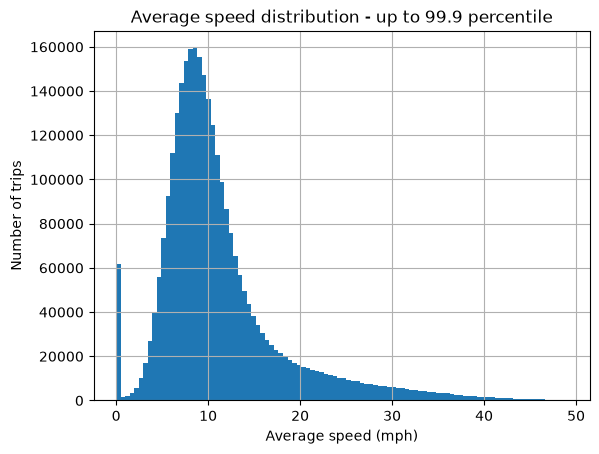

In [92]:
speed_plot_limit = df["average_speed_mph"].quantile(0.999)

df.loc[df["average_speed_mph"].between(0, speed_plot_limit), "average_speed_mph"].hist(bins=100)

plt.title("Average speed distribution - up to 99.9 percentile")
plt.xlabel("Average speed (mph)")
plt.ylabel("Number of trips")
plt.show()

In [123]:
# 2.1

duration_ranges = pd.cut(
    df["trip_duration_minutes"], 
    bins = [
        float("-inf"),
        0,
        1,
        360,
        1200,
        1380,
        1440,
        float("inf"),
    ],
    labels = [
        "<= 0 min",
        "0-1 min",
        "1 min-6 h",
        "6-20 h",
        "20-23 h",
        "23-24 h",
        "> 24 h",
    ],
    right=True
)

duration_range_counts = (duration_ranges.value_counts().sort_index())

duration_range_counts

trip_duration_minutes
<= 0 min         870
0-1 min        34543
1 min-6 h    2927439
6-20 h           304
20-23 h          136
23-24 h         1316
> 24 h            16
Name: count, dtype: int64

In [128]:
# 2.2 

near_24h_mask = df["trip_duration_minutes"].between(1380, 1440, inclusive="left")

corrected_duration_minutes = (1440 - df.loc[near_24h_mask, "trip_duration_minutes"])

corrected_speed_mph = (df.loc[near_24h_mask, "trip_distance"] / (corrected_duration_minutes / 60) )

near_24h_mask = df["trip_duration_minutes"].between(
    1380,
    1440,
    inclusive="left",
)

corrected_duration_minutes = (
    1440 - df.loc[
        near_24h_mask,
        "trip_duration_minutes",
    ]
)

corrected_speed_mph = (
    df.loc[near_24h_mask, "trip_distance"]
    / (corrected_duration_minutes / 60)
)

near_24h_diagnostic = pd.DataFrame({
    "original_duration_minutes":
        df.loc[near_24h_mask, "trip_duration_minutes"],

    "hypothetical_duration_minutes":
        corrected_duration_minutes,

    "trip_distance":
        df.loc[near_24h_mask, "trip_distance"],

    "hypothetical_speed_mph":
        corrected_speed_mph,

    "fare_amount":
        df.loc[near_24h_mask, "fare_amount"],

    "total_amount":
        df.loc[near_24h_mask, "total_amount"],
})

print(near_24h_diagnostic.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

       original_duration_minutes  hypothetical_duration_minutes  trip_distance  hypothetical_speed_mph  fare_amount  total_amount
count                1316.000000                    1316.000000    1316.000000             1316.000000  1316.000000   1316.000000
mean                 1422.336208                      17.663792       2.905585               31.994574    17.902964     24.908435
std                    14.829254                      14.829254       3.508812              221.928853    14.527585     16.861551
min                  1380.066667                       0.016667       0.000000                0.000000    -7.200000    -13.700000
1%                   1381.444167                       0.640833       0.306000                0.584726     4.400000      9.100000
25%                  1413.741667                       5.812500       1.080000                3.824627     9.300000     15.400000
50%                  1426.700000                      13.300000       1.845000            

In [130]:
# 2.3

distance_group_summary = pd.crosstab(
    record_group,
    pd.Series(
        pd.cut(
            df["trip_distance"],
            bins=[
                float("-inf"),
                0,
                50,
                100,
                500,
                float("inf")
            ],
            labels=[
                "<= 0",
                "0-50",
                "50-100",
                "100-500",
                "> 500",
            ]
        ),
        index=df.index,
        name="distance_range"
    )
)

distance_group_percentages = (
    distance_group_summary.div(distance_group_summary.sum(axis=1), axis=0).mul(100).round(4))

print(distance_group_percentages)

distance_range            <= 0     0-50  50-100  100-500   > 500
record_group                                                    
special_missing_group  16.2847  83.6989  0.0014   0.0007  0.0143
standard_group          1.3293  98.6569  0.0124   0.0012  0.0002


In [132]:
# 3.1

exact_duplicate_mask = df.duplicated(keep=False)

print("Rows participating in exact duplicates:", exact_duplicate_mask.sum())
print("Duplicate rows removable with keep='first'", df.duplicated(keep='first').sum())

Rows participating in exact duplicates: 0
Duplicate rows removable with keep='first' 0


In [137]:
# 3.2 
trip_identity_columns = [
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount",
    "total_amount"
]

business_duplicate_mask = df.duplicated(subset=trip_identity_columns, keep=False)

print("Rows participating in possible buisness duplicates:", business_duplicate_mask.sum())
print("Duplicate rows removable with keep='first'", df.duplicated(subset=trip_identity_columns, keep='first').sum())

Rows participating in possible buisness duplicates: 0
Duplicate rows removable with keep='first' 0


In [ ]:
# # 3.3

# business_duplicate_examples = (
#     df.loc[
#         business_duplicate_mask, 
#         trip_identity_columns + [
#             "payment_type", 
#             "RatecodeID", 
#             "store_and_fwd_flag", 
#             "is_special_record", 
#             "is_negative_transaction", 
#         ] 
#     ].sort_values(trip_identity_columns).head(30)
# )

# business_duplicate_examples

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,store_and_fwd_flag,is_special_record,is_negative_transaction


In [150]:
# 4.1

categorical_counts = {
    "VendorID" : df["VendorID"].value_counts(dropna=False).sort_index(),
    "RatecodeID" : df["RatecodeID"].value_counts(dropna=False).sort_index(),
    "payment_type" : df["payment_type"].value_counts(dropna=False).sort_index(),
    "store_and_fwd_flag" : df["store_and_fwd_flag"].value_counts(dropna=False).sort_index(),
    "passenger_count" : df["passenger_count"].value_counts(dropna=False).sort_index()
}

print("categorical_counts:")
for column_name, counts in categorical_counts.items():
    print(f"\n" + "=" * 22)
    print(counts.to_string())

categorical_counts:

VendorID
1.0     729732
2.0    2234632
6.0        260

RatecodeID
1.0     2663350
2.0       98713
3.0        7954
4.0        6365
5.0       19410
6.0           7
99.0      28663
NaN      140162

payment_type
0.0     140162
1.0    2319046
2.0     439191
3.0      19597
4.0      46628

store_and_fwd_flag
N       2813126
Y         11336
None     140162

passenger_count
0.0      31465
1.0    2188739
2.0     405103
3.0      91262
4.0      51974
5.0      33506
6.0      22353
7.0          8
8.0         51
9.0          1
NaN     140162


In [ ]:
# 4.2

location_checks = pd.Series({
    "PULocationID missing" : df["PULocationID"].isna().sum(),
    "DOLocationID missing" : df["DOLocationID"].isna().sum(),
    "PULocationID <=0" : (df["PULocationID"] <= 0).sum(),
    "DOLocationID <=0" : (df["DOLocationID"] <= 0).sum(),
    "PULocationID > 265" : (df["PULocationID"] > 265).sum(),
    "DOLocationID > 265" : (df["PULocationID"] > 265).sum(),
    "Unique pickup location" : df["PULocationID"].nunique(dropna=True),
    "Unique pickup location" : df["DOLocationID"].nunique(dropna=True)
})

print("location_checks:")
location_checks

location_checks:


PULocationID missing        0
DOLocationID missing        0
PULocationID <=0            0
DOLocationID <=0            0
PULocationID > 265          0
DOLocationID > 265          0
Unique pickup location    261
dtype: int64

In [ ]:
passenger_checks = pd.Series({
    "missing passenger_count" : df["passenger_count"].isna().sum(),
    "passenger_count = 0" : (df["passenger_count"]==0).sum(),
    "passenger_count between 1 and 6" : df["passenger_count"].between(0, 6).sum(),
    "passenger_count > 6" : (df["passenger_count"] > 6).sum(),
    "passenger_count < 0" : (df["passenger_count"] < 0).sum(), 
})

print("passenger_checks:")
passenger_checks

passenger_checks:


missing passenger_count             140162
passenger_count = 0                  31465
passenger_count between 1 and 6    2824402
passenger_count > 6                     60
passenger_count < 0                      0
dtype: int64